# Water Quality Prediction Model 1 

Classification (Safe/Unsafe)

In [11]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip




   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE # For handling imbalanced data

In [4]:
df=pd.read_csv("water.csv")

In [5]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
print("Missing Values per columns : ")
print(df.isnull().sum())

Missing Values per columns : 
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


C:\Users\ANAND\AppData\Local\Temp\ipykernel_31576\1651043152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability',data=df,palette='viridis')


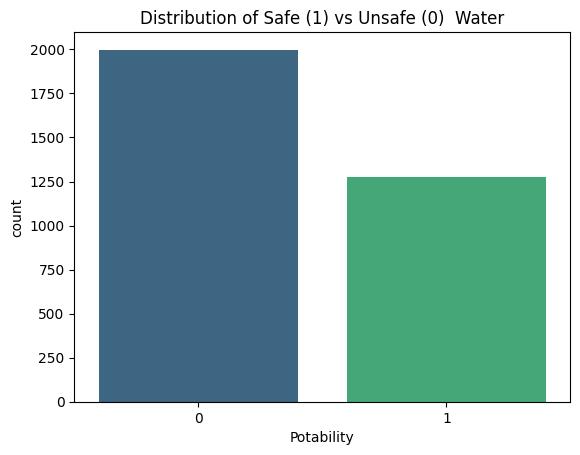

In [8]:
# Target Distribution (Checking for Imbalance)
sns.countplot(x='Potability',data=df,palette='viridis')
plt.title('Distribution of Safe (1) vs Unsafe (0)  Water')
plt.show()

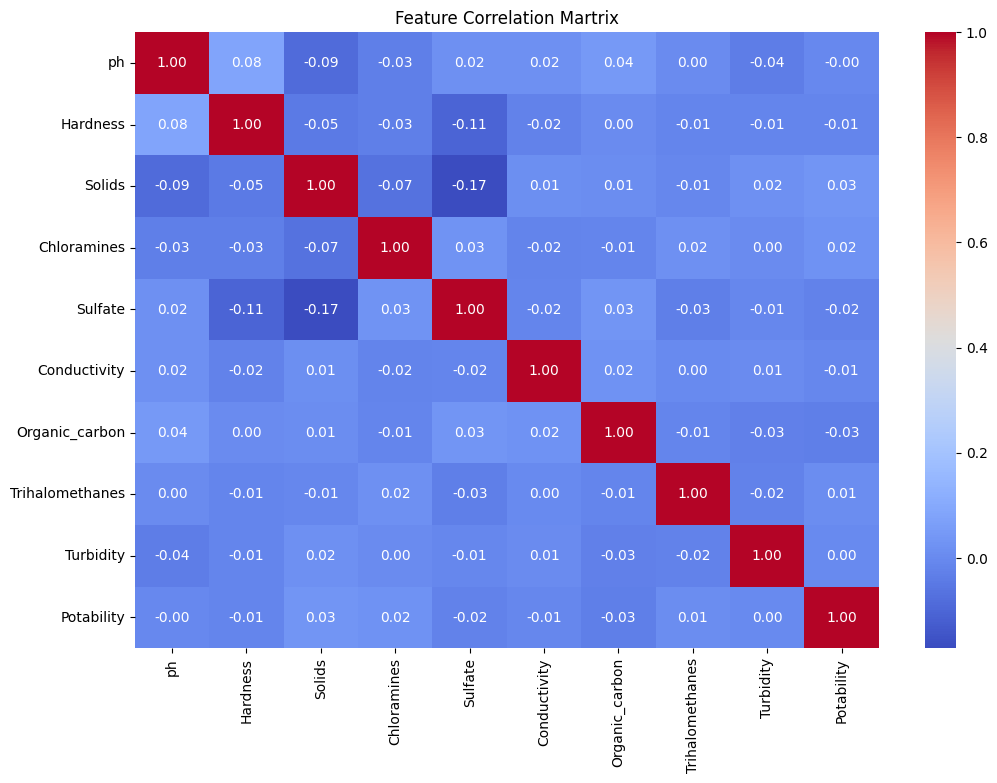

In [9]:
# Correlation Heatmap 
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature Correlation Martrix')
plt.show()

In [15]:
# Filling missing values based on potability class
df['ph']=df['ph'].fillna(df.groupby('Potability')['ph'].transform('mean'))
df['Sulfate']=df['Sulfate'].fillna(df.groupby('Potability')['Sulfate'].transform('mean'))
df['Trihalomethanes']=df['Trihalomethanes'].fillna(df.groupby('Potability')['Trihalomethanes'].transform('mean'))


In [16]:
#Feature Selection for model 1

X=df.drop('Potability',axis=1)
y=df['Potability']

In [17]:
#Balancing the dataset using SMOTE
smote=SMOTE(random_state=42)
X_res,y_res=smote.fit_resample(X,y)

In [18]:
# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X_res,y_res,test_size=0.2,random_state=42)

In [19]:
# Initializing and training the XGBoost Classifier
model_1 = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, eval_metric='logloss')
model_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
# evaluation
y_pred=model_1.predict(X_test)
print(f"Accuracy:{accuracy_score(y_test,y_pred):.2%}")
print("Classification Report : \n",classification_report(y_test,y_pred))

Accuracy:81.50%
Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.76      0.80       394
           1       0.79      0.86      0.83       406

    accuracy                           0.81       800
   macro avg       0.82      0.81      0.81       800
weighted avg       0.82      0.81      0.81       800



C:\Users\ANAND\AppData\Local\Temp\ipykernel_31576\2102414993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names,palette='magma')


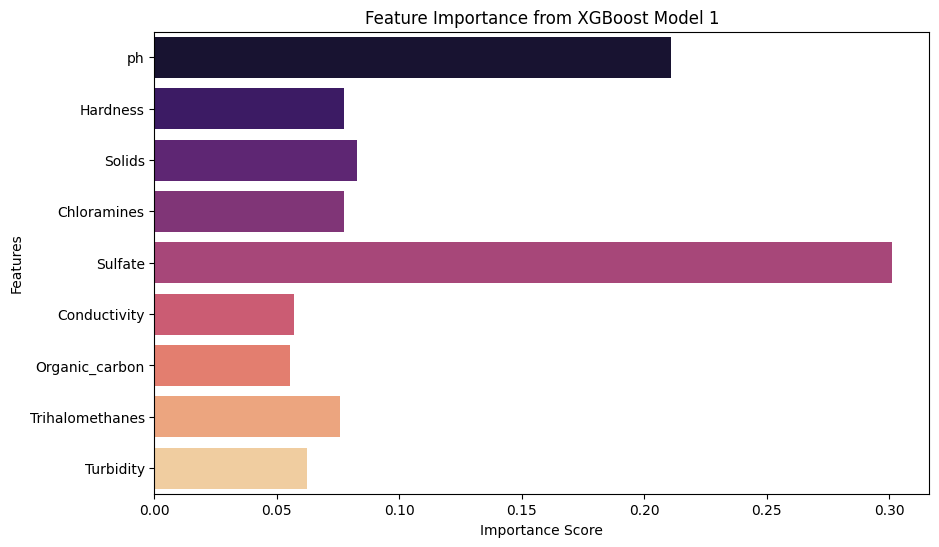

In [26]:
# Extracting feature importance from the trained model 1

importances = model_1.feature_importances_
feature_names = X.columns

#Visualizing feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names,palette='magma')
plt.title('Feature Importance from XGBoost Model 1')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [31]:
import joblib

# Save the model to a file
# We use .joblib because it is more efficient for large arrays than pickle
joblib.dump(model_1, 'water_safety_classifier.joblib')



['water_safety_classifier.joblib']

In [30]:
# Save the scaling/balancing parameters if necessary
# In our case, XGBoost handles the raw input, but we must remember 
# the features we used: X.columns.tolist()
print("Model 1 has been officially saved and is ready for production!")

Model 1 has been officially saved and is ready for production!


In [33]:
X.columns.tolist()

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

In [ ]:
# Create a mock user input with all 9 parameters
# Example values: [ph=7.2, Hardness=200, Solids=20000, Chloramines=7.3, Sulfate=333, 
#                  Conductivity=400, Organic_carbon=14, Trihalomethanes=66, Turbidity=4]
sample_water = np.array([[7.2, 200.0, 20000.0, 7.3, 333.0, 400.0, 14.0, 66.0, 4.0]])

# 4. Run the simulation
prediction = model_1.predict(sample_water)
probability = model_1.predict_proba(sample_water)

print("-" * 30)
if prediction[0] == 1:
    print(f"Result: SAFE to drink")
    print(f"Confidence: {probability[0][1]:.2%}")
else:
    print(f"Result: UNSAFE to drink")
    print(f"Confidence: {probability[0][0]:.2%}")
print("-" * 30)

------------------------------
Result: SAFE to drink
Confidence: 71.19%
------------------------------
